# Notebook 01 — Exploratory Data Analysis: Credit Risk

**Project**: Ethiopian Fintech Analytics Platform  
**Author**: Eyob Nebyou  
**Dataset**: Give Me Some Credit (Kaggle)  
**Goal**: Understand the credit default dataset before any modeling.

---

## What We're Answering

1. What does the dataset look like? (shape, types, missing values)
2. How imbalanced is the target class?
3. Which features are most correlated with default?
4. Are there any obvious outliers we need to handle?
5. What features should we engineer?

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath('..'))  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Project modules
from src.data.loader import load_credit_data, get_dataset_summary
from src.visualization.plots import (
    plot_class_distribution,
    plot_missing_heatmap,
    plot_numeric_distributions,
    plot_correlation_matrix,
    save_figure
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the Data

In [2]:
# ── Load credit dataset ─────────────────────────────────────────
# Make sure you've downloaded cs-training.csv to data/raw/credit/
# See docs/data_download.md for instructions
df = load_credit_data()
print(df.head())

Loading credit data from: /Users/eyobnebyou/Desktop/ethiopian-fintech-analytics/data/raw/credit/cs-training.csv
  Shape: (150000, 11)
  Default rate: 6.68%
  Missing values:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

   default_target  RevolvingUtilizationOfUnsecuredLines  age  \
1               1                                0.7661   45   
2               0                                0.9572   40   
3               0                                0.6582   38   
4               0                                0.2338   30   
5               0                                0.9072   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2     0.8030      9120.0000   
2                                     0     0.1219      2600.0000   
3                                     1     0.0851      3042.0000   
4                                     0     0.0360      3300.0000   
5                         

In [3]:
# ── Full dataset summary ────────────────────────────────────────
get_dataset_summary(df, name='Give Me Some Credit')


  Give Me Some Credit Summary
  Rows:     150,000
  Columns:  11

  Data types:
int64      7
float64    4

  Missing values (columns with > 0 missing):
                    count     pct
MonthlyIncome       29731 19.8200
NumberOfDependents   3924  2.6200

  Numeric column stats:
       default_target  RevolvingUtilizationOfUnsecuredLines         age  NumberOfTime30-59DaysPastDueNotWorse   DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
count     150000.0000                           150000.0000 150000.0000                           150000.0000 150000.0000    120269.0000                      150000.0000              150000.0000                   150000.0000                           150000.0000         146076.0000
mean           0.0700                                6.0500     52.3000                                0.4200    353.0100      6670.2200                  

## 2. Target Variable — Class Imbalance

Credit default datasets are almost always imbalanced. Let's see how bad it is.  
This will directly influence our modeling strategy (SMOTE, class weights, threshold tuning).

default_target
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%
Class ratio (majority:minority) = 14.0:1
Figure saved: /Users/eyobnebyou/Desktop/ethiopian-fintech-analytics/reports/01_class_distribution_credit.png


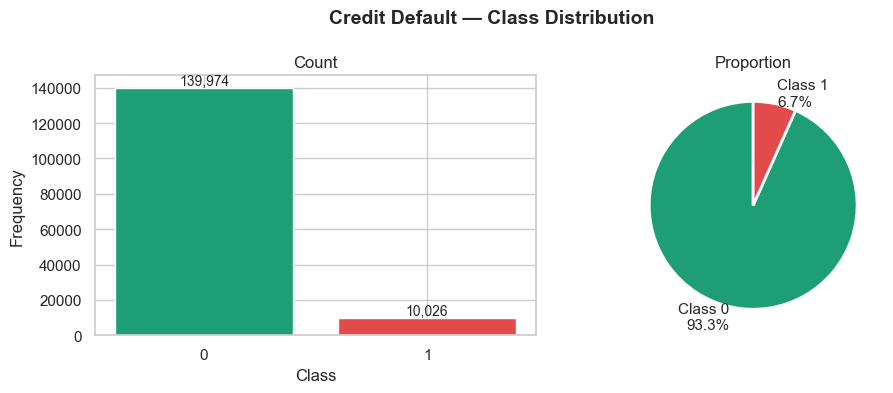

In [4]:
# ── Class distribution ──────────────────────────────────────────
target = 'default_target'
print(df[target].value_counts())
print(f'\nDefault rate: {df[target].mean():.2%}')
print(f'Class ratio (majority:minority) = {(df[target]==0).sum() / (df[target]==1).sum():.1f}:1')

fig = plot_class_distribution(df[target], title='Credit Default — Class Distribution')
save_figure(fig, '01_class_distribution_credit.png')
plt.show()

**Finding**: Record your observation here after running the cell.  
Example: *"The dataset is ~93% non-default and ~7% default — a 13:1 imbalance. We will need SMOTE or class weighting."*

## 3. Missing Values

In [9]:
# ── Missing value analysis ──────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
print(missing_df)

fig = plot_missing_heatmap(df, title='Credit Data — Missing Values')
if fig:
    save_figure(fig, '01_missing_values_credit.png')
    plt.show()

Columns with missing values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.


In [8]:
# ── Data Imputation: Fixing Missing Values ──────────────────────

# 1. MonthlyIncome: 19.8% missing
# We use the MEDIAN because it's robust to those extreme outliers (the $3M earners)
income_median = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median)

# 2. NumberOfDependents: 2.6% missing
# Standard practice: Assume missing means 0 dependents
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 3. Validation: Verify the "Heatmap" is now empty
remaining_missing = df.isnull().sum().sum()
print(f"✅ Missing values handled.")
print(f"Total missing values remaining: {remaining_missing}")
print(f"Substituted Median Income: ${income_median:,.2f}")

✅ Missing values handled.
Total missing values remaining: 0
Substituted Median Income: $5,400.00


## 4. Feature Distributions

We'll plot each numeric feature, split by the target class, to visually identify which features separate defaulters from non-defaulters.

Figure saved: /Users/eyobnebyou/Desktop/ethiopian-fintech-analytics/reports/01_feature_distributions_credit.png


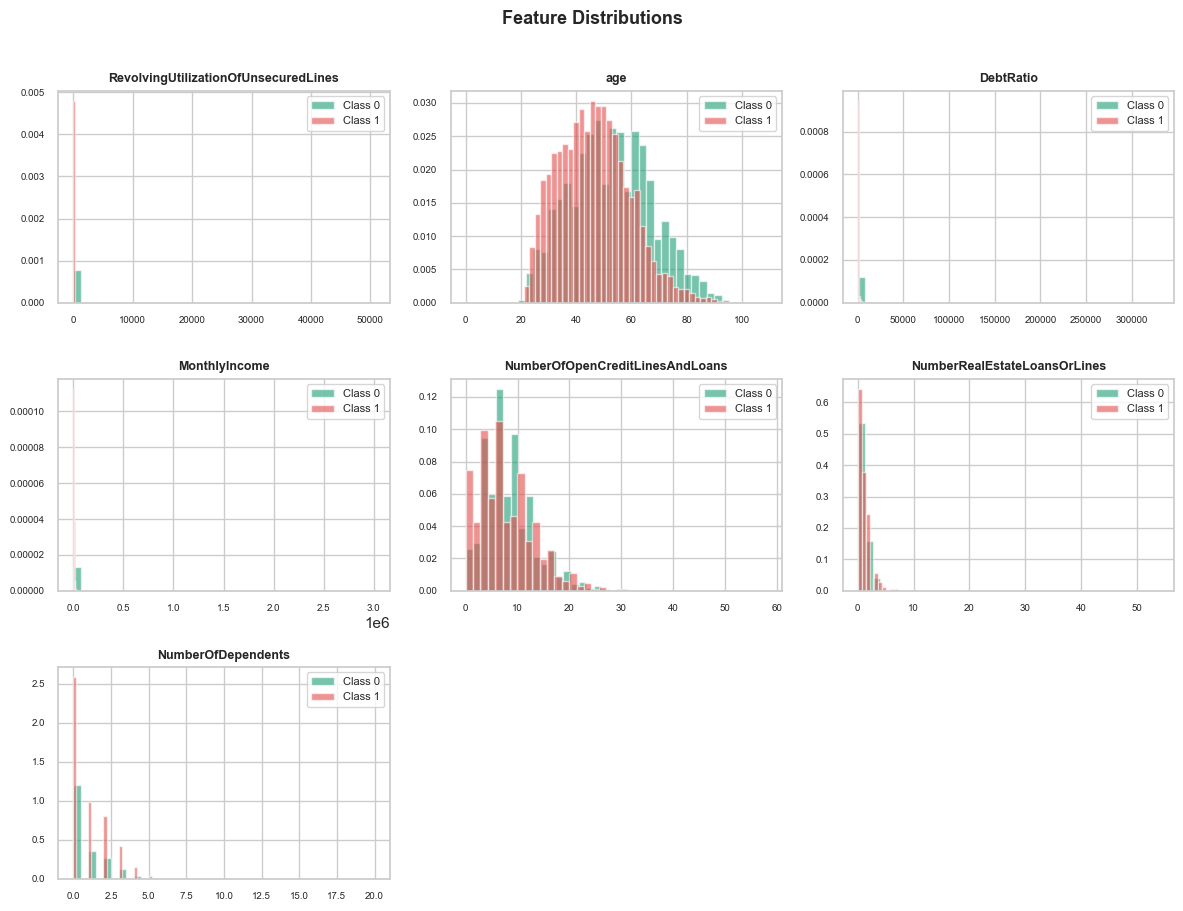

In [6]:
# ── Numeric feature distributions by target ─────────────────────
numeric_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

# Filter to columns that exist in df
numeric_features = [c for c in numeric_features if c in df.columns]

fig = plot_numeric_distributions(df, numeric_features, target=target, ncols=3)
save_figure(fig, '01_feature_distributions_credit.png')
plt.show()

Figure saved: /Users/eyobnebyou/Desktop/ethiopian-fintech-analytics/reports/01_feature_distributions_cleaned.png


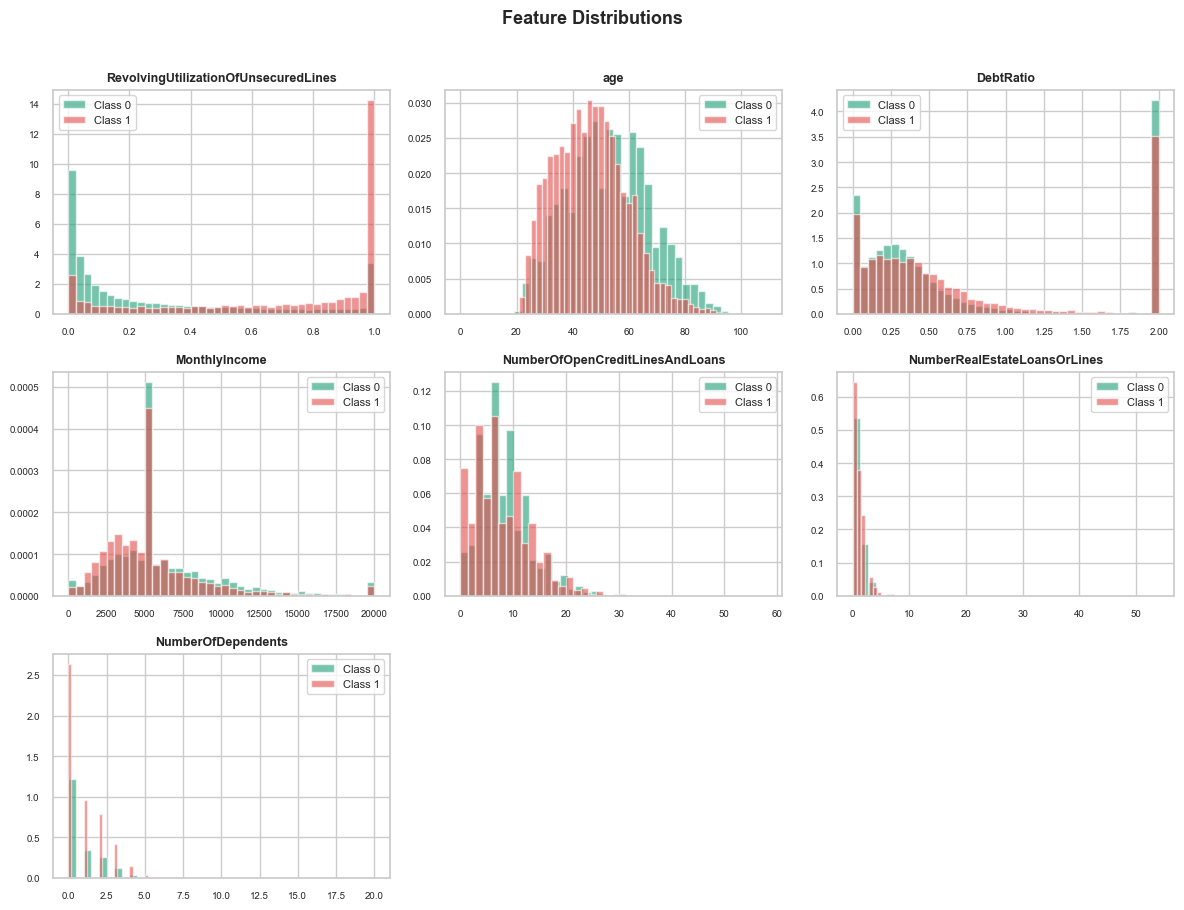

In [10]:
# ── 1. Cap Outliers to "Zoom In" the plots ──────────────────────

# Cap Utilization at 1.0 (100%) - This fixes the first chart
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

# Cap DebtRatio at 2.0 - This fixes the third chart
df['DebtRatio'] = df['DebtRatio'].clip(upper=2.0)

# Cap MonthlyIncome at 20,000 - This fixes the fourth chart
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=20000)


# ── 2. Render the Distributions ────────────────────────────────

numeric_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

# Ensure the columns exist
numeric_features = [c for c in numeric_features if c in df.columns]

# Generate the plots
fig = plot_numeric_distributions(df, numeric_features, target=target, ncols=3)
save_figure(fig, '01_feature_distributions_cleaned.png')
plt.show()

✅ Age fixed. Minimum age is now: 21
Figure saved: /Users/eyobnebyou/Desktop/ethiopian-fintech-analytics/reports/01_feature_distributions_final.png


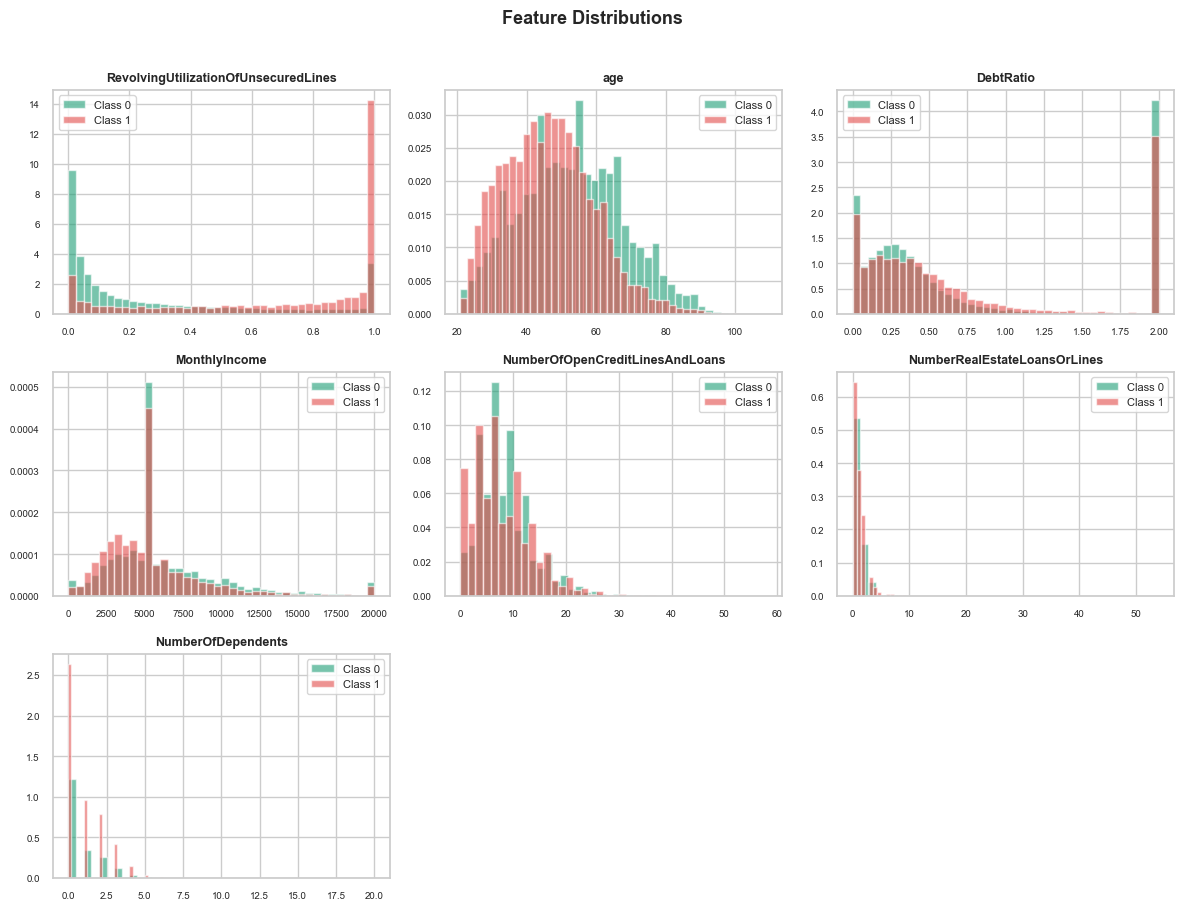

In [11]:
# ── 1. Fix Age Logic Errors ─────────────────────────────────────

# We keep only rows where age is 18 or older
# This removes the "0" values and any other children in the dataset
df = df[df['age'] >= 18]

print(f"✅ Age fixed. Minimum age is now: {df['age'].min()}")

# ── 2. Re-run Final Distributions ───────────────────────────────

numeric_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

# Ensure we use the target variable defined earlier
fig = plot_numeric_distributions(df, numeric_features, target='default_target', ncols=3)
save_figure(fig, '01_feature_distributions_final.png')
plt.show()

## 5. Outlier Analysis

In [22]:
# 1. Logic Fix: Remove the impossible ages (keeps everyone 18 to 96)
df = df[(df['age'] >= 18) & (df['age'] <= 96)]

# 2. Utilization Fix: Cap at 1.35 (your Upper bound)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.35)

# 3. DebtRatio Fix: Cap at 1.91 (your Upper bound)
df['DebtRatio'] = df['DebtRatio'].clip(upper=1.91)

# 4. MonthlyIncome Fix: Cap at 12645.50 (your Upper bound)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=12645.50)

print("✅ Data constraints applied!")

✅ Data constraints applied!


In [25]:
# ── Outlier detection with IQR ──────────────────────────────────
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    return n_outliers, lower, upper

print(f'{'Column':<45} {'Outliers':>10} {'Lower':>12} {'Upper':>12}')
print('-' * 82)
for col in numeric_features:
    n, lo, hi = detect_outliers_iqr(df, col)
    pct = n / len(df) * 100
    print(f'{col:<45} {n:>7,} ({pct:.1f}%) {lo:>12.2f} {hi:>12.2f}')
    print(f"Verified Age Range: {df['age'].min()} to {df['age'].max()}")

Column                                          Outliers        Lower        Upper
----------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines                0 (0.0%)        -0.76         1.35
Verified Age Range: 21 to 96
age                                                 0 (0.0%)         8.00        96.00
Verified Age Range: 21 to 96
DebtRatio                                      31,296 (20.9%)        -0.86         1.91
Verified Age Range: 21 to 96
MonthlyIncome                                   9,149 (6.1%)     -1341.88     12645.12
Verified Age Range: 21 to 96
NumberOfOpenCreditLinesAndLoans                 3,980 (2.7%)        -4.00        20.00
Verified Age Range: 21 to 96
NumberRealEstateLoansOrLines                      793 (0.5%)        -3.00         5.00
Verified Age Range: 21 to 96
NumberOfDependents                             13,336 (8.9%)        -1.50         2.50
Verified Age Range: 21 to 96


## 6. Correlation Analysis

In [ ]:
# ── Correlation with target ─────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[target].drop(target).sort_values(ascending=False)

print('Feature correlations with default_target:')
print(correlations.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E24B4A' if x > 0 else '#1D9E75' for x in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Default Target')
ax.set_title('Feature Correlations with Credit Default', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_figure(fig, '01_correlations_credit.png')
plt.show()

In [ ]:
# ── Full correlation matrix ─────────────────────────────────────
fig = plot_correlation_matrix(df, title='Credit Data — Correlation Matrix')
save_figure(fig, '01_correlation_matrix_credit.png')
plt.show()

## 7. Age Analysis — A Business-Relevant Feature

In [ ]:
# ── Default rate by age group ───────────────────────────────────
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 120],
                             labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])
    default_by_age = df.groupby('age_group')[target].mean() * 100

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(default_by_age.index.astype(str), default_by_age.values,
                  color='#534AB7', alpha=0.85)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate by Age Group', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, default_by_age.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_figure(fig, '01_default_rate_by_age.png')
    plt.show()

    # Clean up temp column
    df.drop(columns=['age_group'], inplace=True)

## 8. EDA Summary & Findings

Fill this in after completing all cells above:

| Finding | Detail |
|---|---|
| Dataset size | rows × cols |
| Default rate | ~X% |
| Class ratio | X:1 |
| Missing columns | MonthlyIncome (X%), NumberOfDependents (X%) |
| Top correlated feature | ? |
| Notable outlier column | ? |
| Age group with highest default | ? |

**Next steps (Week 3)**:
- Impute MonthlyIncome and NumberOfDependents with median
- Cap outliers at 99th percentile
- Engineer `delinquency_score`, `debt_to_income`, `is_young_borrower`
- Apply SMOTE to handle class imbalance before training

In [ ]:
# ── Save a cleaned version for next notebook ───────────────────
from src.data.loader import save_processed
save_processed(df, 'credit_raw_explored.parquet')
print('EDA complete. Proceed to notebook 02 for fraud EDA.')